✅ API conectada
OK
(1536,)
      candidate  origin_cost  residual_norm  projected_norm
0      grounded     0.394980       0.628474        0.218382
2  hallucinated     0.795938       0.892154        0.330082
1       verbose     0.826879       0.909329        0.188715


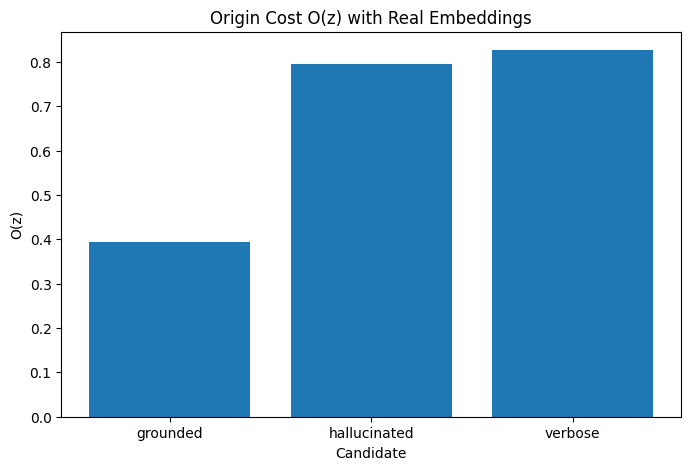


--- PRECISE ---

Semantic grounding matters for reliable LLM outputs because it ensures that the model's generated text is meaningfully connected to real-world concepts or data, reducing ambiguity and errors. Without semantic grounding, outputs may be coherent but factually incorrect, contextually irrelevant, or nonsensical, undermining trust and usefulness. Grounding helps align the model’s language with true knowledge, improving accuracy, interpretability, and reliability.

--- EXPANSIVE ---

Semantic grounding is essential for reliable outputs from large language models (LLMs) because it anchors the model’s responses in meaningful, contextually relevant understanding rather than mere pattern matching. Here’s a conceptual expansion on why this matters:

1. **From Correlation to Comprehension**  
   Most LLMs are trained on vast text corpora and excel at predicting plausible next words or sentences based on statistical correlations. Without semantic grounding, the model might generat

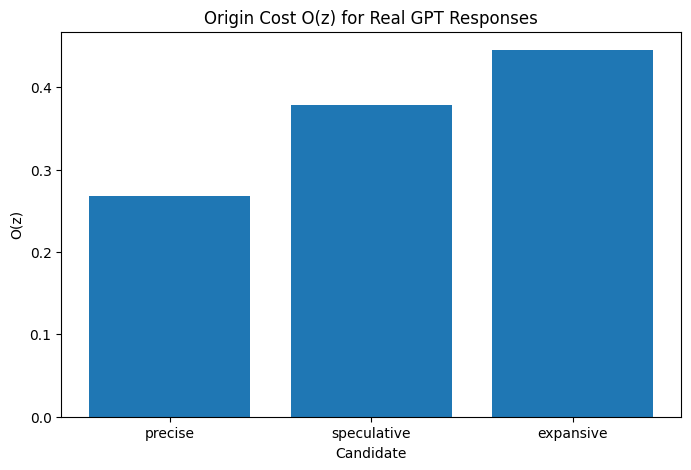

Best candidate by O(z):
precise

Text:

Semantic grounding matters for reliable LLM outputs because it ensures that the model's generated text is meaningfully connected to real-world concepts or data, reducing ambiguity and errors. Without semantic grounding, outputs may be coherent but factually incorrect, contextually irrelevant, or nonsensical, undermining trust and usefulness. Grounding helps align the model’s language with true knowledge, improving accuracy, interpretability, and reliability.
     candidate  avg_origin_cost  std_origin_cost  avg_response_len
1      precise         0.245418         0.060337         37.000000
2  speculative         0.327046         0.041166        183.666667
0    expansive         0.404705         0.017056        375.000000


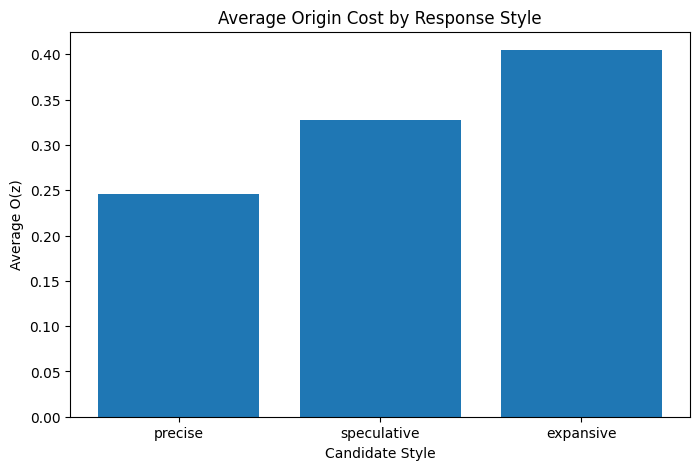

✅ Archivos guardados:
- ace_benchmark_results.csv
- ace_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Config guardada


In [6]:
!pip install -q openai numpy matplotlib pandas

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from getpass import getpass
from openai import OpenAI

if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass("🔑 Introduce tu OPENAI_API_KEY: ")

client = OpenAI()
print("✅ API conectada")

def get_embeddings(texts, model="text-embedding-3-small"):
    if isinstance(texts, str):
        texts = [texts]

    response = client.embeddings.create(
        model=model,
        input=texts
    )

    return [np.array(item.embedding, dtype=float) for item in response.data]

vec = get_embeddings("Semantic grounding matters for reliable LLM outputs.")[0]
print("OK")
print(vec.shape)

def build_reference_subspace(prompt_vec, axiom_vecs, knowledge_vecs, center=True, svd_tol=1e-10):
    all_vectors = [prompt_vec] + axiom_vecs + knowledge_vecs
    matrix = np.vstack(all_vectors)

    centroid = np.mean(matrix, axis=0) if center else None
    work_matrix = matrix - centroid if center else matrix.copy()

    _, s, vt = np.linalg.svd(work_matrix, full_matrices=False)
    rank = int(np.sum(s > svd_tol))
    basis = vt[:rank].T

    return {
        "basis": basis,
        "centroid": centroid,
        "rank": rank,
        "singular_values": s,
    }

def project_vector(vector, basis):
    return basis @ (basis.T @ vector)

def compute_origin_cost(candidate_vec, subspace):
    basis = subspace["basis"]
    centroid = subspace["centroid"]

    work_vec = candidate_vec - centroid if centroid is not None else candidate_vec.copy()
    projected = project_vector(work_vec, basis)
    residual = work_vec - projected

    residual_norm = float(np.linalg.norm(residual))
    projected_norm = float(np.linalg.norm(projected))
    origin_cost = float(residual_norm ** 2)

    return {
        "origin_cost": origin_cost,
        "residual_norm": residual_norm,
        "projected_norm": projected_norm,
    }

prompt = "Explain why semantic grounding matters for reliable LLM outputs."

axioms = [
    "A response should remain structurally aligned with its originating context.",
    "Semantic drift increases hallucination risk.",
]

knowledge = [
    "Grounded responses tend to preserve relevance and coherence.",
    "Ungrounded responses often become verbose, speculative, or inconsistent.",
]

candidates = {
    "grounded": "Semantic grounding matters because it keeps the response tied to the original context and reduces drift.",
    "verbose": "Language models operate in many dimensions of possibility, and meaning can unfold through many interpretive layers beyond immediate context.",
    "hallucinated": "Semantic grounding matters mainly because it improves hardware memory allocation in transformer GPUs."
}

prompt_vec = get_embeddings(prompt)[0]
axiom_vecs = get_embeddings(axioms)
knowledge_vecs = get_embeddings(knowledge)
candidate_vecs = {name: get_embeddings(text)[0] for name, text in candidates.items()}

subspace = build_reference_subspace(prompt_vec, axiom_vecs, knowledge_vecs)

results = {}
for name, vec in candidate_vecs.items():
    results[name] = compute_origin_cost(vec, subspace)

rows = []
for name, r in results.items():
    rows.append({
        "candidate": name,
        "origin_cost": r["origin_cost"],
        "residual_norm": r["residual_norm"],
        "projected_norm": r["projected_norm"],
    })

df = pd.DataFrame(rows).sort_values("origin_cost")
print(df)

plt.figure(figsize=(8, 5))
plt.bar(df["candidate"], df["origin_cost"])
plt.title("Origin Cost O(z) with Real Embeddings")
plt.ylabel("O(z)")
plt.xlabel("Candidate")
plt.show()

def generate_candidate(prompt_text, system_text, model="gpt-4.1-mini"):
    response = client.responses.create(
        model=model,
        input=[
            {"role": "system", "content": system_text},
            {"role": "user", "content": prompt_text},
        ],
    )
    return response.output_text


systems = {
    "precise": "Answer briefly and stay strictly anchored to the prompt.",
    "expansive": "Answer with broad interpretive freedom and conceptual expansion.",
    "speculative": "Answer creatively, even if some assumptions are not explicitly grounded.",
}

gpt_candidates = {}
for label, sys_msg in systems.items():
    gpt_candidates[label] = generate_candidate(prompt, sys_msg)
    print(f"\n--- {label.upper()} ---\n")
    print(gpt_candidates[label])

    gpt_candidate_vecs = {
    name: get_embeddings(text)[0]
    for name, text in gpt_candidates.items()
}

gpt_results = {}
for name, vec in gpt_candidate_vecs.items():
    gpt_results[name] = compute_origin_cost(vec, subspace)

gpt_rows = []
for name, r in gpt_results.items():
    gpt_rows.append({
        "candidate": name,
        "origin_cost": r["origin_cost"],
        "residual_norm": r["residual_norm"],
        "projected_norm": r["projected_norm"],
        "text": gpt_candidates[name],
    })

gpt_df = pd.DataFrame(gpt_rows).sort_values("origin_cost")
print(gpt_df[["candidate", "origin_cost", "residual_norm", "projected_norm"]])

plt.figure(figsize=(8, 5))
plt.bar(gpt_df["candidate"], gpt_df["origin_cost"])
plt.title("Origin Cost O(z) for Real GPT Responses")
plt.ylabel("O(z)")
plt.xlabel("Candidate")
plt.show()

best_row = gpt_df.iloc[0]

print("Best candidate by O(z):")
print(best_row["candidate"])
print("\nText:\n")
print(best_row["text"])

benchmark_cases = [
    {
        "name": "semantic_grounding",
        "prompt": "Explain why semantic grounding matters for reliable LLM outputs.",
        "axioms": [
            "A response should remain aligned with its source context.",
            "Semantic drift increases hallucination risk.",
        ],
        "knowledge": [
            "Grounded responses preserve coherence.",
            "Ungrounded responses tend toward speculation.",
        ],
    },
    {
        "name": "missing_context",
        "prompt": "Why does missing context destabilize a language model response?",
        "axioms": [
            "Ambiguity increases competing interpretations.",
            "Competing interpretations raise structural uncertainty.",
        ],
        "knowledge": [
            "High uncertainty degrades response stability.",
            "Clarification narrows the semantic search space.",
        ],
    },
    {
        "name": "clarification_vs_assumption",
        "prompt": "Why is asking for clarification often better than guessing in ambiguous prompts?",
        "axioms": [
            "Assumptions can introduce semantic drift.",
            "Clarification reduces ambiguity before response generation.",
        ],
        "knowledge": [
            "Ambiguous prompts can produce multiple incompatible interpretations.",
            "Clarifying the prompt improves precision and reliability.",
        ],
    },
]

systems = {
    "precise": "Answer briefly and stay strictly anchored to the prompt.",
    "expansive": "Answer with broad interpretive freedom and conceptual expansion.",
    "speculative": "Answer creatively, even if some assumptions are not explicitly grounded.",
}

benchmark_rows = []

for case in benchmark_cases:
    prompt_vec = get_embeddings(case["prompt"])[0]
    axiom_vecs = get_embeddings(case["axioms"])
    knowledge_vecs = get_embeddings(case["knowledge"])

    subspace = build_reference_subspace(prompt_vec, axiom_vecs, knowledge_vecs)

    case_candidates = {}
    for label, sys_msg in systems.items():
        case_candidates[label] = generate_candidate(case["prompt"], sys_msg)

    for label, text in case_candidates.items():
        vec = get_embeddings(text)[0]
        score = compute_origin_cost(vec, subspace)

        benchmark_rows.append({
            "case": case["name"],
            "candidate": label,
            "origin_cost": score["origin_cost"],
            "residual_norm": score["residual_norm"],
            "projected_norm": score["projected_norm"],
            "response_len": len(text.split()),
            "text": text,
        })

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_df

summary_df = (
    benchmark_df.groupby("candidate", as_index=False)
    .agg(
        avg_origin_cost=("origin_cost", "mean"),
        std_origin_cost=("origin_cost", "std"),
        avg_response_len=("response_len", "mean"),
    )
    .sort_values("avg_origin_cost")
)

print(summary_df)

plt.figure(figsize=(8, 5))
plt.bar(summary_df["candidate"], summary_df["avg_origin_cost"])
plt.title("Average Origin Cost by Response Style")
plt.ylabel("Average O(z)")
plt.xlabel("Candidate Style")
plt.show()

benchmark_df.to_csv("ace_benchmark_results.csv", index=False)
summary_df.to_csv("ace_summary.csv", index=False)

print("✅ Archivos guardados:")
print("- ace_benchmark_results.csv")
print("- ace_summary.csv")

from google.colab import files

files.download("ace_benchmark_results.csv")
files.download("ace_summary.csv")

import json

config = {
    "cases": benchmark_cases,
    "systems": systems,
    "embedding_model": "text-embedding-3-small"
}

with open("ace_experiment_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("✅ Config guardada")